In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from plot_neural import *
from plot_sim_results import * 

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

### Data
Choose trial with trial_version == 0 (1-target no-barrier). After filtering, there are 592 trials (with 36 trial type/ maze configurations). After subsetting, do Z-scored transformation. See details in read_nlb_maze.ipynb.

### Modification of double flow matching
Currently, the flow vector allows for lag-h ($h = 0,1,...$) coupling, with coupling in data/ ambience space (tried with latent space coupling --> super difficult to learn). In other words,

$$v(x_{k\delta t + t}^{\tau}|\tau, \{x_{k\delta t}^1,..., x_{(k-1)\delta t}^1\}),$$

for $t\in[0,\delta t]$.

### Code modification
Now, allow for...

1. **Dynamic covariate**: the covariate will be linear interpolated within $\delta t$ interval (special for trial time).
2. **Static covariate**: the covariate will stay constant within $\delta t$ interval.
3. **Lag-h**: see above

### Results

1. PCA: Just stack all data together and do PCA. Show...
   
   - scree plot
   - 2D projection (orange -> blue, start = circle, end = cursor)
   - 3D projection
   - Trial trajectory for each PC
3. Results of fitted model (only do lag-h, no other covariates)
   
   - simulated trajectories in ambience space (tau = 1.0, red = data, black = simulated)
   - simulated trajectories in latent space (tau = 0.0)
   - low-D trajectories

# 1. Read Data

In [2]:
folder_data = 'data/mc_maze'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [3]:
print(len(dset_samples))
print(dset_samples[0].shape)

592
(2997, 137)


In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

In [5]:
train_meta['trial_info'].keys()

dict_keys(['trial_type', 'start_time', 'stop_time', 'trial_version', 'maze_id', 'success', 'target_on_time', 'go_cue_time', 'move_onset_time', 'rt', 'delay', 'num_targets', 'target_pos', 'num_barriers', 'barrier_pos', 'active_target'])

In [6]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]

In [7]:
trial_type_unique = np.unique(trial_type_use)

In [8]:
trial_type_unique.shape

(36,)

# 2. brute-force PCA

In [9]:
mean, components, explained_var, explained_var_ratio, transform = pca_stream(dset_samples, n_components=None)

## 2.1 Scree Plot

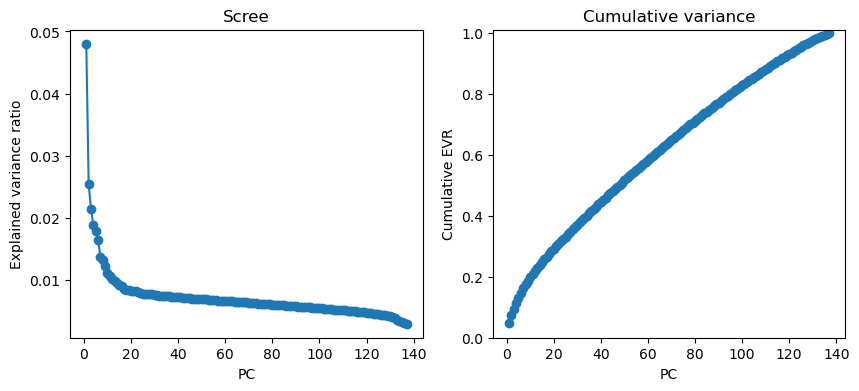

In [10]:
plot_scree(explained_var, explained_var_ratio)

## 2.2 2D projection

orange dot = start; blue arrow = stop

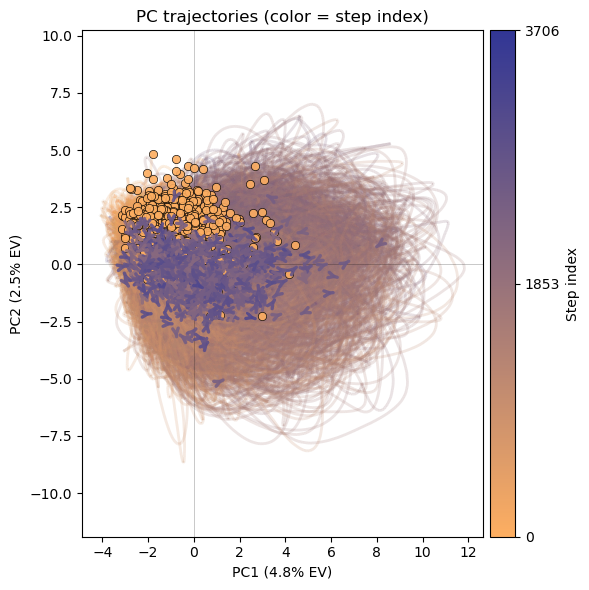

In [11]:
plot_trial_trajectories_gradient_steps(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),   # or any subset
    comps=(0, 1),
    evr=explained_var_ratio,
    linewidth=2.0,
    start_marker_size=36,
    alpha=0.2,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    fig_w = 6, fig_h = 6
)

In [12]:
# trial_target = trial_type_unique[0]
# plot_trial_trajectories_gradient_steps(
#     transform,
#     dset_samples,
#     trial_indices= np.where(trial_type_use == trial_target)[0],   # or any subset
#     comps=(0, 1),
#     evr=explained_var_ratio,
#     linewidth=2.0,
#     start_marker_size=36,
#     alpha=0.2,
#     start_marker_alpha=0.9,
#     end_arrow_alpha=0.9,
#     fig_w = 6, fig_h = 6,
#     title = "trial_type = " + str(trial_target)
# )

## 2.3 3D projection

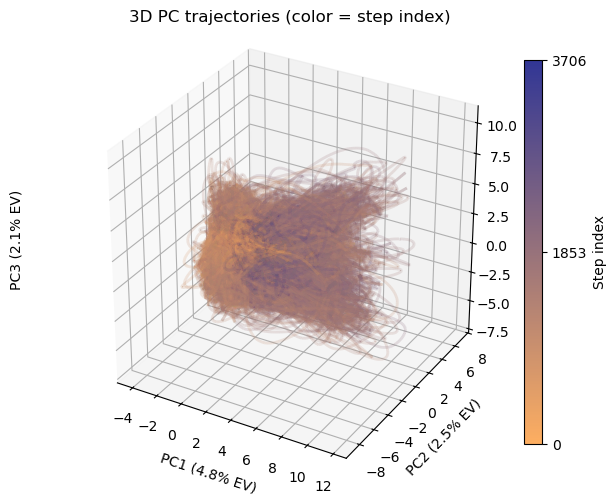

In [13]:
plot_trial_trajectories_gradient_steps_3d(
    transform,
    dset_samples,
    trial_indices=np.arange(len(dset_samples)),  # or choose a subset
    comps=(0, 1, 2),
    evr=explained_var_ratio,
    start_marker_alpha=0.9,
    end_arrow_alpha=0.9,
    alpha = 0.2
)

In [14]:
# plot_trial_trajectories_gradient_steps_3d(
#     transform,
#     dset_samples,
#     trial_indices= np.where(trial_type_use == trial_target)[0],  # or choose a subset
#     comps=(0, 1, 2),
#     evr=explained_var_ratio,
#     start_marker_alpha=0.9,
#     end_arrow_alpha=0.9,
#     alpha = 0.2,
#     title = "trial_type = " + str(trial_target)
# )

## 2.3 trajectory for each PC

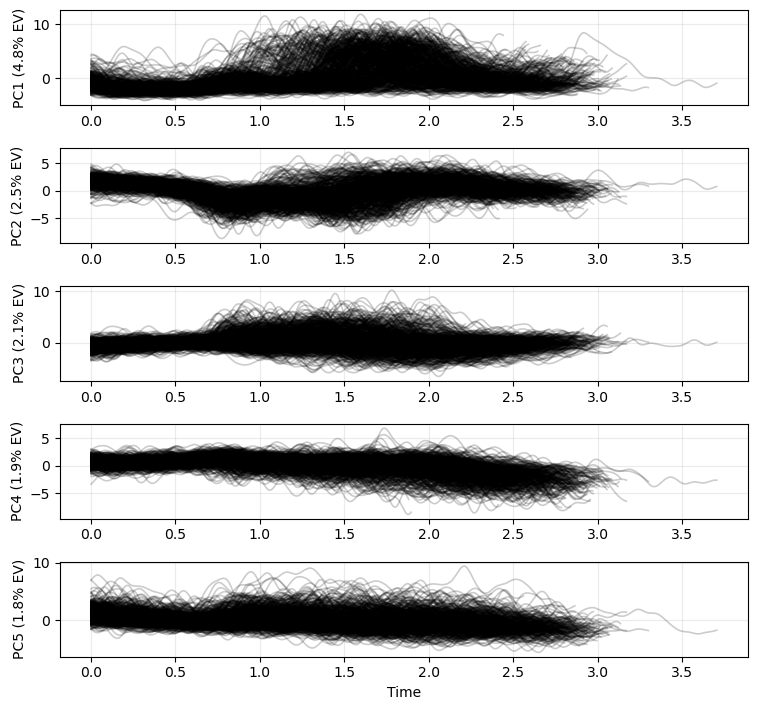

In [15]:
plot_pc_time_series(
    transform, dset_samples,
    pcs=np.arange(5),
    trial_indices=np.arange(len(dset_samples)),
    labels= None,      # trial_type_use
    evr=explained_var_ratio,
    dt=0.001, # can be None
    alpha = 0.2,
    fig_w= 8,
    fig_h_per = 1.5
)

# 3. Model fit

In [16]:
dt = 0.001
# folder_data = 'out/z_scored/maze/dim3_lag5/data'
# folder = 'out/z_scored/maze/dim3_lag5/00000-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
# pkl_path = folder + '/network-snapshot-1000000.pkl'
folder_data = 'out/z_scored/maze/dim3_lag5/data'
folder = 'out/z_scored/maze/dim3_lag5/00002-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-500000.pkl'

dim_preserve = 3

## 3.1 Read Data & Model

**latent dimension = 3, lag (h) = 5**

In [17]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
lagRead_samples = np.load(folder_data + "/lag_cov_list.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
lag_raw = lagRead_samples['samples']
dset_samples = []
lag_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))
    lag_samples.append(np.asarray(lag_raw[ii], dtype=np.float64))
lag = lag_samples[0].shape[1] // dset_samples[0].shape[1] - 1
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
net = net.to(device).eval()
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

In [18]:
# # version 1: global clamp (results are similar)
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value, max_value]) # give some space

# version 2: clamp dim-by-dim (results are similar)
padded_arrays = [np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)),
                        mode='constant', constant_values=np.nan) 
                 for arr in dset_samples]
stacked = np.stack(padded_arrays, axis=0)  # Shape [n_trial, T_max, dim]

min_vals = np.nanmin(stacked, axis=(0, 1))  # Shape [dim]
max_vals = np.nanmax(stacked, axis=(0, 1))  # Shape [dim]

clamp_range = np.stack([min_vals, max_vals], axis=1)  # Shape [dim, 2]
clamp_range[:,0] = clamp_range[:,0] - 1
clamp_range[:,1] = clamp_range[:,1] + 1

## 3.2 generated trajectories

### data space (tau = 1.0)

In [19]:
traj_sim_tau1, lag_cov_list = generate_traj(dyn_net, dset_samples,
                                            n_step = T_max, tau = 1.0,
                                            lag_samples = lag_samples, device = device, lag = lag,
                                            include_x0_tau = False,
                                            oracle = False, lag_cov_list_pre = None,
                                           clamp_range = clamp_range)

100%|██████████████████████████████████████| 3701/3701 [00:20<00:00, 184.97it/s]


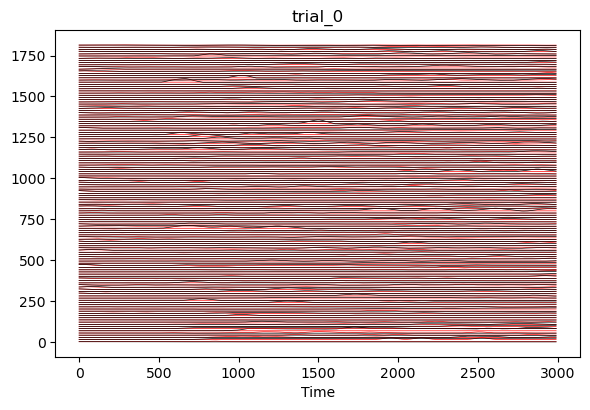

In [20]:
trial_plot = 0
plotTraj(dset_samples[trial_plot], data_sim = traj_sim_tau1[trial_plot], title = 'trial_' + str(trial_plot))

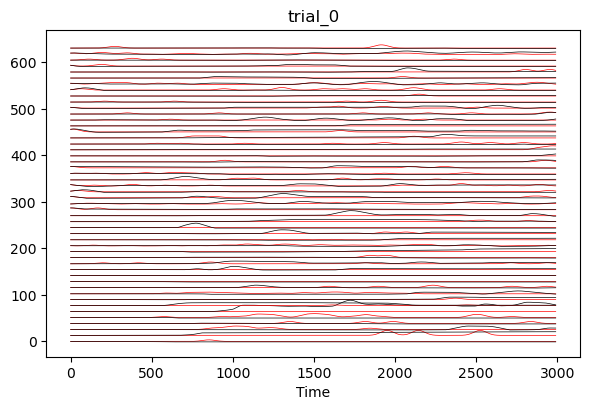

In [21]:
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau1[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### latent space (tau = 0.0)

In [22]:
traj_sim_tau0, _ = generate_traj(dyn_net, dset_samples,
                                 n_step = T_max, tau = 0.0,
                                 lag_samples = lag_samples, device = device, lag = lag,
                                 include_x0_tau = False,
                                 oracle = False, lag_cov_list_pre = lag_cov_list, flow_net = flow_net,
                                clamp_range = clamp_range)

project starting points to latent


100%|██████████████████████████████████████| 3701/3701 [00:19<00:00, 187.69it/s]


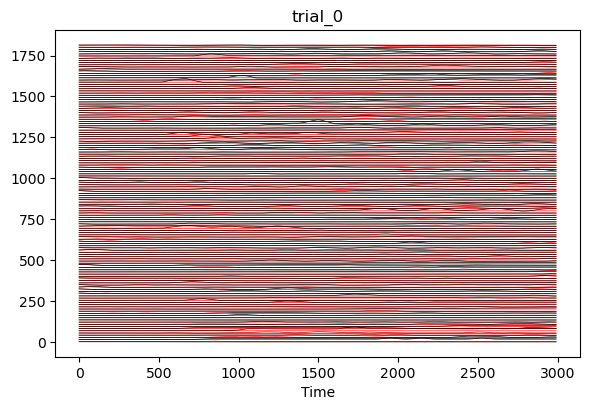

In [23]:
trial_plot = 0
plotTraj(dset_samples[trial_plot], data_sim = traj_sim_tau0[trial_plot], title = 'trial_' + str(trial_plot))

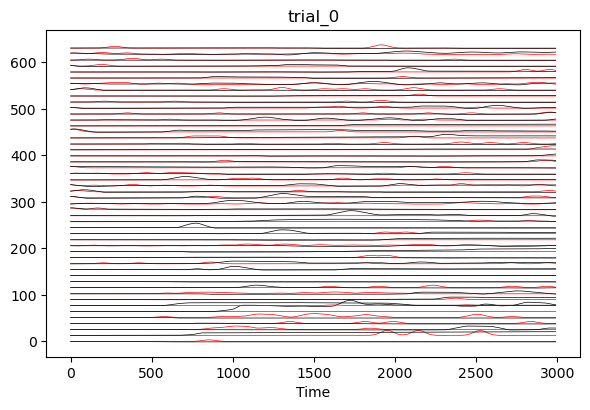

In [24]:
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau0[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

Look similar to ambience space: good, reconstruction is OK.

## 3.3 latent trajectories

In [25]:
mu_traj = []
encoder.eval()
with torch.inference_mode():
    for ii in tqdm(range(len(traj_sim_tau0))):
        X = torch.from_numpy(traj_sim_tau0[ii]).to(device=device, dtype=torch.float32)  # [T, in_dim]
        mu = encoder.mu(X)                         # [T, out_dim]
        mu_traj_tmp = mu[:, :dim_preserve].detach().cpu()   # [T, dim_preserve]
        mu_traj.append(mu_traj_tmp)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 2513.72it/s]


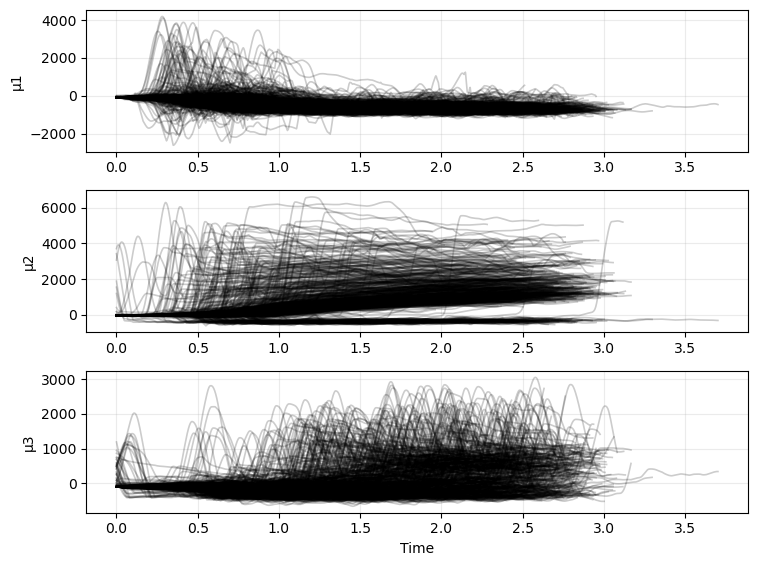

In [26]:
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)

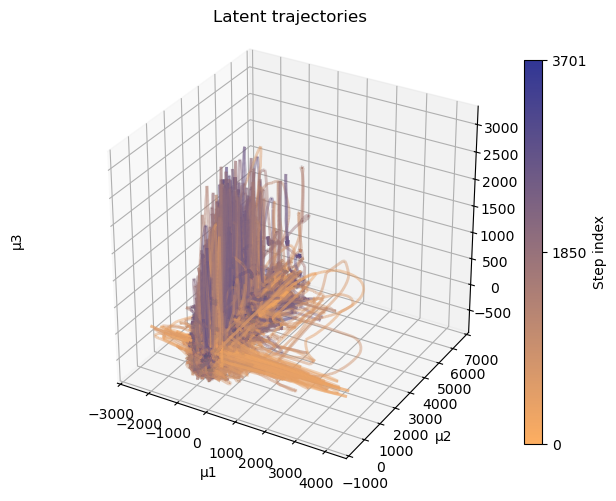

In [27]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, trial_indices=np.arange(len(mu_traj_np)), dims=(0,1,2),
    title="Latent trajectories"
)

Seems has some structure, but how to interpret the results?